# Prediciendo diabetes con Random Forest



## Paso 1: Carga del conjunto de datos



In [1]:
import pandas as pd
import numpy as np


url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df = pd.read_csv(url)


cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
df.fillna(df.median(), inplace=True)


from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Datos cargados y divididos:")
print(f"  - Entrenamiento: {X_train.shape[0]} muestras")
print(f"  - Prueba: {X_test.shape[0]} muestras")

Datos cargados y divididos:
  - Entrenamiento: 614 muestras
  - Prueba: 154 muestras


## Paso 2: Construye un Random Forest



In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print("=== Random Forest (configuración por defecto) ===")
print(f"Accuracy: {acc_base:.4f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_base))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_base))

=== Random Forest (configuración por defecto) ===
Accuracy: 0.7792

Matriz de confusión:
[[88 12]
 [22 32]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



n_estimators=10: Accuracy = 0.7727
n_estimators=50: Accuracy = 0.7468
n_estimators=100: Accuracy = 0.7792
n_estimators=150: Accuracy = 0.7403
n_estimators=200: Accuracy = 0.7403
n_estimators=300: Accuracy = 0.7338
n_estimators=500: Accuracy = 0.7338


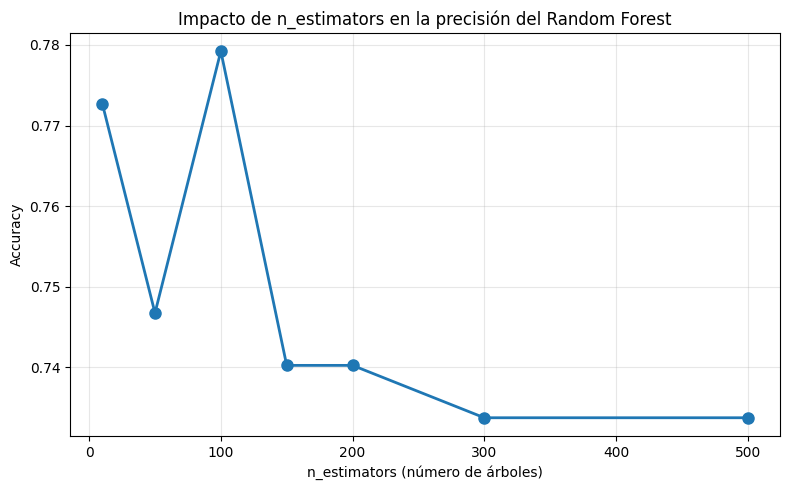

In [3]:

n_estimators_values = [10, 50, 100, 150, 200, 300, 500]
accuracies_n_est = []

for n in n_estimators_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_n_est.append(acc)
    print(f"n_estimators={n}: Accuracy = {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_values, accuracies_n_est, "o-", linewidth=2, markersize=8)
plt.xlabel("n_estimators (número de árboles)")
plt.ylabel("Accuracy")
plt.title("Impacto de n_estimators en la precisión del Random Forest")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

max_depth=3: Accuracy = 0.7273
max_depth=5: Accuracy = 0.7403
max_depth=7: Accuracy = 0.7403
max_depth=10: Accuracy = 0.7532
max_depth=15: Accuracy = 0.7532
max_depth=20: Accuracy = 0.7792
max_depth=None: Accuracy = 0.7792


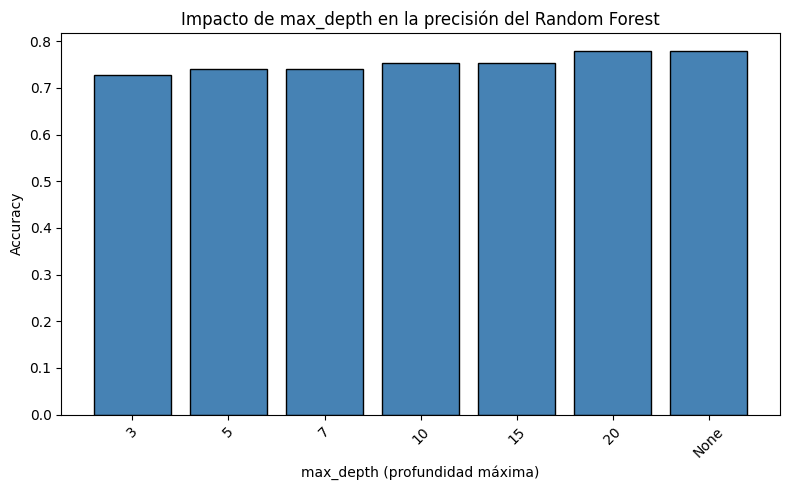

In [4]:

max_depth_values = [3, 5, 7, 10, 15, 20, None]
accuracies_depth = []
labels_depth = [str(d) if d else "None" for d in max_depth_values]

for depth in max_depth_values:
    rf = RandomForestClassifier(max_depth=depth, n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_depth.append(acc)
    print(f"max_depth={depth}: Accuracy = {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(labels_depth, accuracies_depth, color="steelblue", edgecolor="black")
plt.xlabel("max_depth (profundidad máxima)")
plt.ylabel("Accuracy")
plt.title("Impacto de max_depth en la precisión del Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

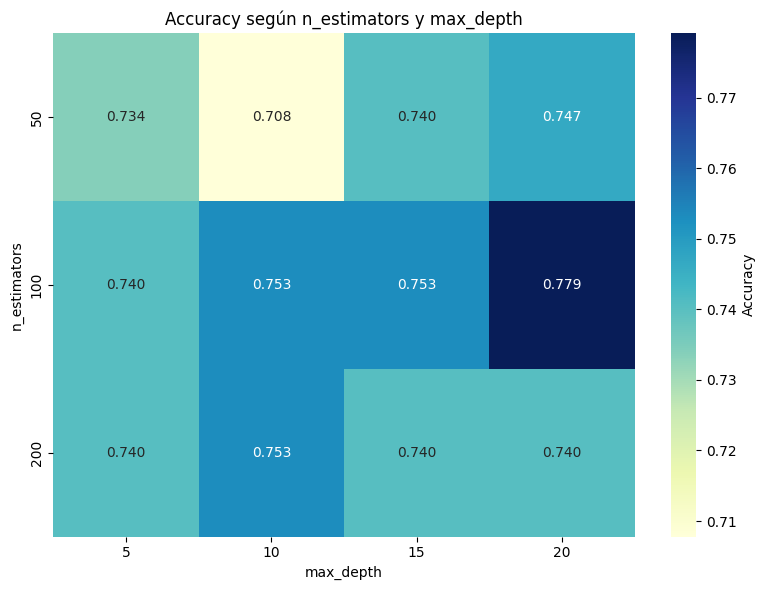


=== Modelo final optimizado ===
Accuracy: 0.7403


In [5]:

n_est_range = [50, 100, 200]
depth_range = [5, 10, 15, 20]
results = []

for n in n_est_range:
    row = []
    for d in depth_range:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        rf.fit(X_train, y_train)
        acc = accuracy_score(y_test, rf.predict(X_test))
        row.append(acc)
    results.append(row)

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    results,
    xticklabels=depth_range,
    yticklabels=n_est_range,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "Accuracy"},
)
plt.xlabel("max_depth")
plt.ylabel("n_estimators")
plt.title("Accuracy según n_estimators y max_depth")
plt.tight_layout()
plt.show()


best_rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_final = best_rf.predict(X_test)
print(f"\n=== Modelo final optimizado ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")

## Paso 3: Guarda el modelo



In [6]:
import joblib
from pathlib import Path


cwd = Path(".").resolve()
project_root = cwd if (cwd / "src").exists() else cwd.parent
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True, parents=True)


model_path = models_dir / "random_forest_diabetes.pkl"
joblib.dump(best_rf, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: C:\Users\Farmatodo Kike\Documents\4Geeks Data science\Prediciendo-diabetes\models\random_forest_diabetes.pkl
